# 1. Imports e Configuração

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions.database import load_data, load_failure_types

# 2. Carregamento de dados

In [3]:
df = load_data()
label_map = load_failure_types()

print(f'Shape: {df.shape}')
print(f'Periodo: {df["timestamp"].min()} ate {df["timestamp"].max()}')
print(f'Motores unicos: {df["motor_id"].nunique()}')
df.head()

Shape: (30000, 10)
Periodo: 2026-01-01 00:00:00 ate 2026-01-02 00:59:00
Motores unicos: 20


,motor_id,timestamp,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a,falha,fabricante,modelo,potencia_kw
0,1,2026-01-01 00:00:00,1767.32,2.574,72.22,12.37,0,Siemens,1LE0,22.0
1,1,2026-01-01 00:01:00,1783.54,2.858,71.72,13.75,0,Siemens,1LE0,22.0
2,1,2026-01-01 00:02:00,1819.29,1.815,67.94,13.24,0,Siemens,1LE0,22.0
3,1,2026-01-01 00:03:00,1808.19,2.641,75.53,12.18,0,Siemens,1LE0,22.0
4,1,2026-01-01 00:04:00,1815.67,3.457,72.20,12.24,0,Siemens,1LE0,22.0


# 3. Qualidade dos dados

In [4]:
print('Tipos das colunas:')
print(df.dtypes)
print('\nValores nulos por coluna:')
print(df.isnull().sum())

Tipos das colunas:
motor_id                  int64
timestamp        datetime64[us]
rotacao_rpm             float64
vibracao_mm_s           float64
temperatura_c           float64
corrente_a              float64
falha                     int64
fabricante                  str
modelo                      str
potencia_kw             float64
dtype: object

Valores nulos por coluna:
motor_id         0
timestamp        0
rotacao_rpm      0
vibracao_mm_s    0
temperatura_c    0
corrente_a       0
falha            0
fabricante       0
modelo           0
potencia_kw      0
dtype: int64


# 4. Distruibuição de Classes de falha

Contagem por classe:
  Normal              :  26291 (87.6%)
  Desbalanceamento    :   1205 (4.0%)
  Superaquecimento    :   1718 (5.7%)
  Falha mecanica      :    786 (2.6%)


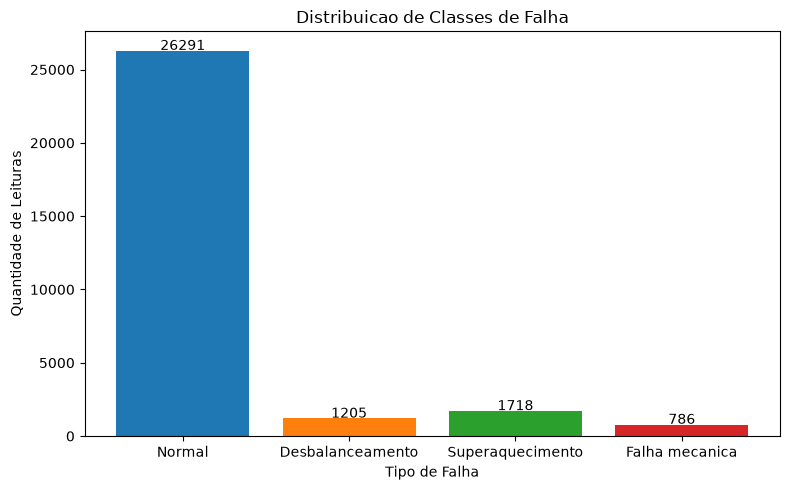

In [5]:
print("Contagem por classe:")
contagem = df["falha"].value_counts().sort_index()
for codigo, qtd in contagem.items():
    pct = qtd / len(df) * 100
    print(f"  {label_map[codigo]:20s}: {qtd:6d} ({pct:.1f}%)")

labels = [label_map[i] for i in contagem.index]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, contagem.values, color=sns.color_palette("tab10", len(labels)))
ax.set_title("Distribuicao de Classes de Falha")
ax.set_xlabel("Tipo de Falha")
ax.set_ylabel("Quantidade de Leituras")
for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(val), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# 5. Estatisticas Descritivas por Classe

In [6]:
features = ['rotacao_rpm', 'vibracao_mm_s', 'temperatura_c', 'corrente_a']

df['tipo_falha'] = df['falha'].map(label_map)
df.groupby('tipo_falha')[features].mean().round(2)

,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a
tipo_falha,,,,
Desbalanceamento,1762.44,7.29,69.12,12.62
Falha mecanica,1570.53,6.10,68.72,14.05
Normal,1776.08,2.73,68.50,12.32
Superaquecimento,1768.16,3.03,84.30,14.59


# 6. Correla;áo entre Features

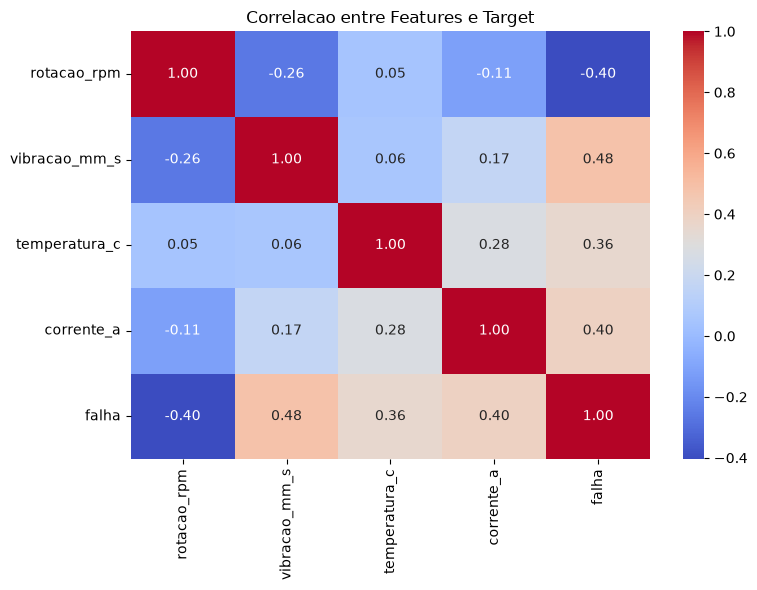

In [7]:

cols = ["rotacao_rpm", "vibracao_mm_s", "temperatura_c", "corrente_a", "falha"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlacao entre Features e Target")
plt.tight_layout()
plt.show()

# 7. Serie Temporal de um Motor

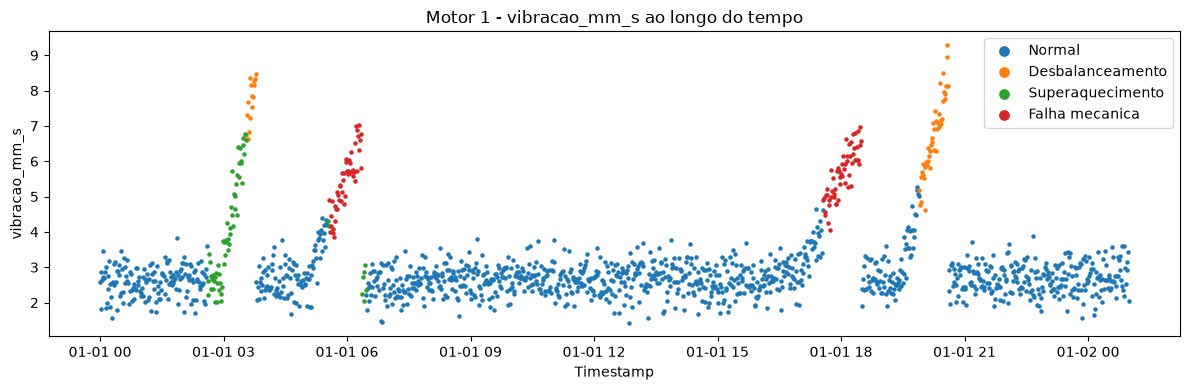

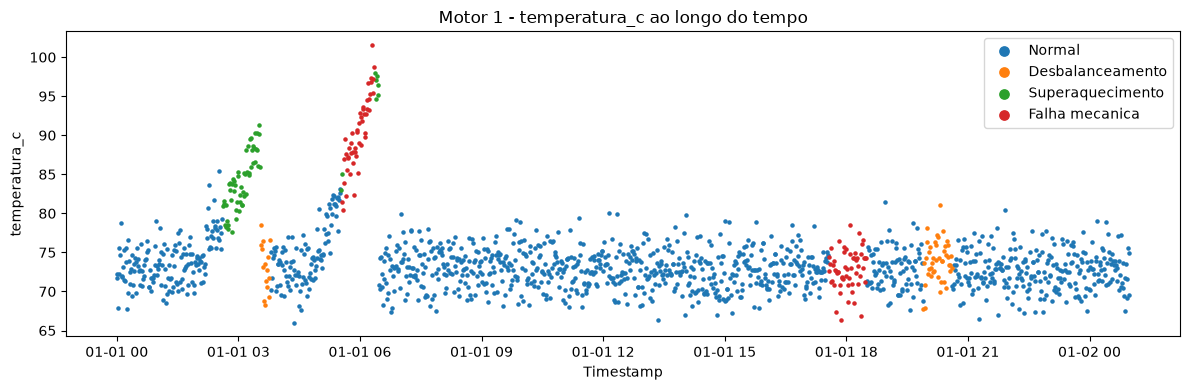

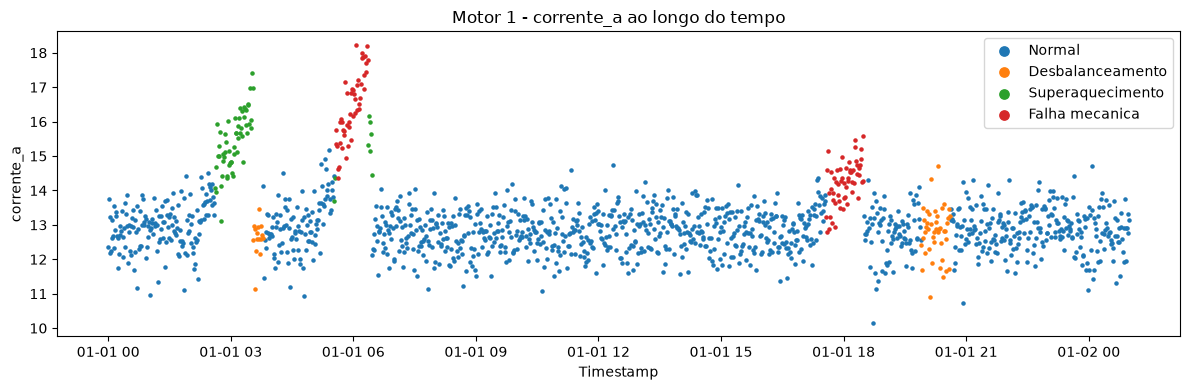

In [8]:
motor_df = df[df["motor_id"] == 1].sort_values("timestamp")

for feature in ["vibracao_mm_s", "temperatura_c", "corrente_a"]:
    fig, ax = plt.subplots(figsize=(12, 4))
    for falha_val, group in motor_df.groupby("falha"):
        ax.scatter(group["timestamp"], group[feature],
                   label=label_map[falha_val], s=5)
    ax.set_title(f"Motor 1 - {feature} ao longo do tempo")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(feature)
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()

# 8. Boxplot por Classe

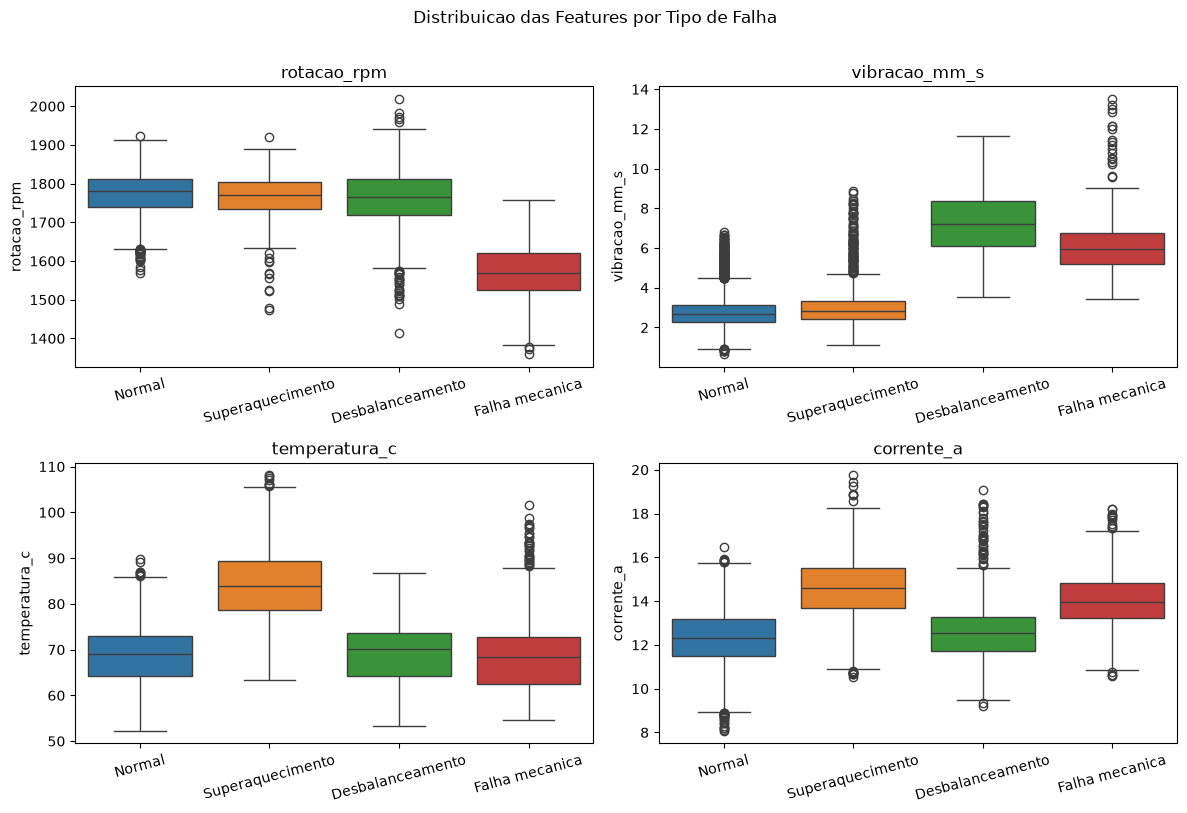

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="tipo_falha", y=col, hue="tipo_falha",
                legend=False, ax=ax, palette="tab10")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Distribuicao das Features por Tipo de Falha", y=1.01)
plt.tight_layout()
plt.show()